In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/Admin/Downloads/studentsPerformance.csv")
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  mathscore  readingscore  writingscore  
0                    none       72.0            72            74  
1               completed       69.0            90            88  
2                    none       90.0            95            93  
3                    none       47.0            57            44  
4                    none       76.0            78            75  


In [3]:
#Check missing values
print(df.isnull().sum())

gender                          0
race/ethnicity                  0
parental level of education     0
lunch                           0
test preparation course         0
mathscore                      15
readingscore                    0
writingscore                    0
dtype: int64


In [4]:
#Fill missing values
# Numeric → mean
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())



In [5]:
#Remove duplicates
df.drop_duplicates(inplace=True)

In [6]:
#Identify Skewness
print(df[num_cols].skew())

mathscore      -0.289526
readingscore   -0.259105
writingscore   -0.289444
dtype: float64


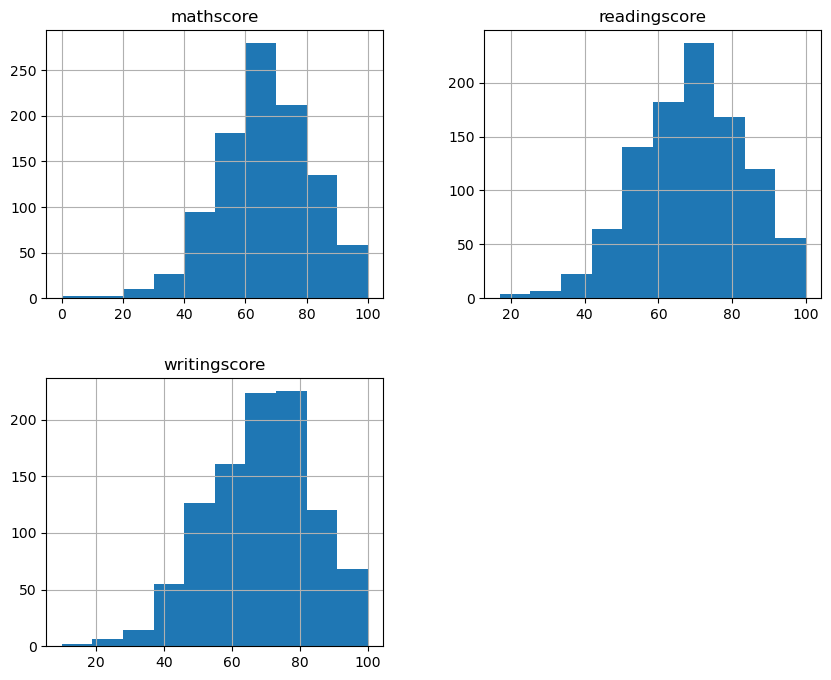

In [7]:
df[num_cols].hist(figsize=(10,8))
plt.show()

In [8]:
#Min-Max Scaling (Change Scale)
for col in num_cols:
    df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

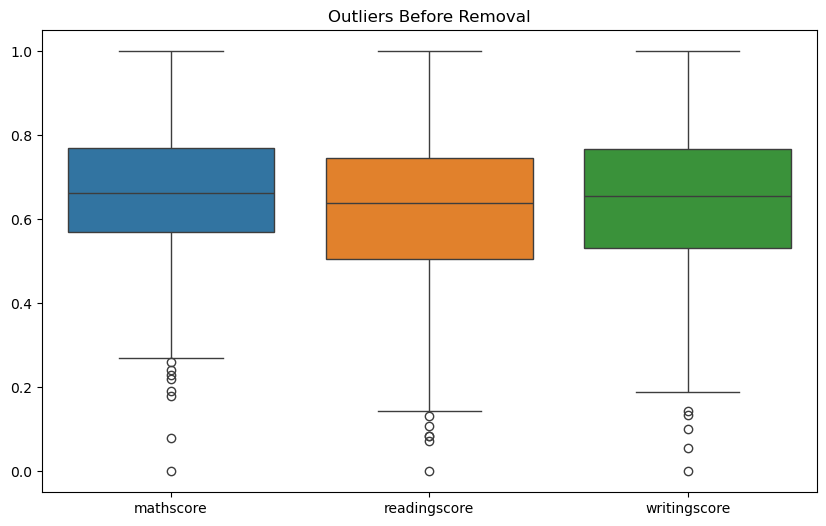

In [9]:
# Boxplot to visualize outliers

plt.figure(figsize=(10,6))
sns.boxplot(data=df[num_cols])

plt.title("Outliers Before Removal")
plt.show()

In [10]:
outlier_count = {}

for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_count[col] = len(outliers)

print("Outliers in each column:")
print(outlier_count)

Outliers in each column:
{'mathscore': 8, 'readingscore': 6, 'writingscore': 5}


In [11]:
df_clean = df.copy()

for col in num_cols:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower) &
        (df_clean[col] <= upper)
    ]

In [12]:
print("Skewness Before Outlier Removal:\n")
print(df[num_cols].skew())

Skewness Before Outlier Removal:

mathscore      -0.289526
readingscore   -0.259105
writingscore   -0.289444
dtype: float64


In [13]:
print("Skewness After Outlier Removal:\n")
print(df_clean[num_cols].skew())

Skewness After Outlier Removal:

mathscore      -0.032155
readingscore   -0.077671
writingscore   -0.084362
dtype: float64


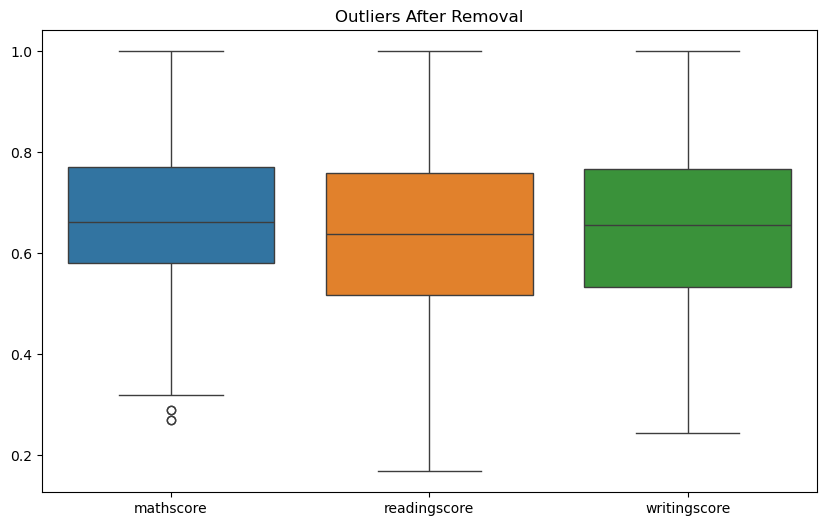

In [14]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df_clean[num_cols])

plt.title("Outliers After Removal")
plt.show()

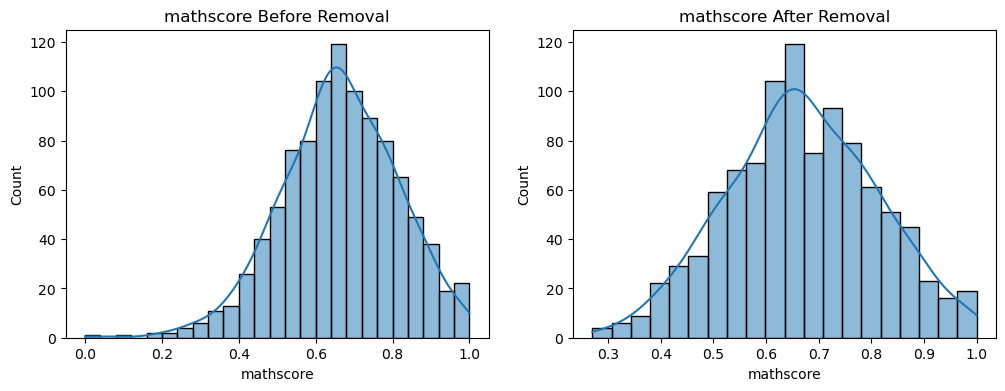

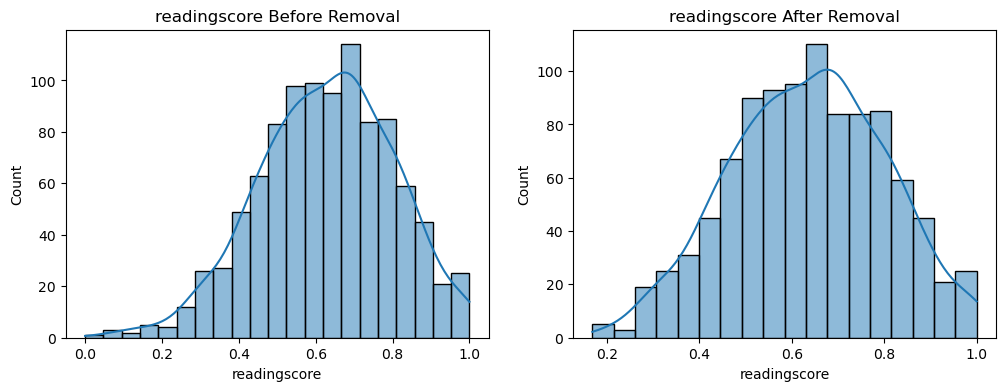

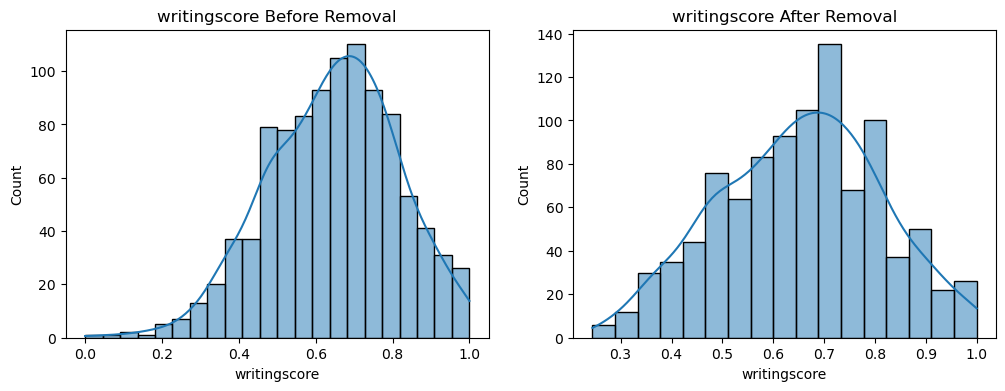

In [15]:
for col in num_cols:

    plt.figure(figsize=(12,4))

    # BEFORE
    plt.subplot(1,2,1)

    sns.histplot(df[col], kde=True)

    plt.title(f"{col} Before Removal")

    # AFTER
    plt.subplot(1,2,2)

    sns.histplot(df_clean[col], kde=True)

    plt.title(f"{col} After Removal")

    plt.show()

In [17]:
df_log = df_clean.copy()

for col in num_cols:

    if abs(df_log[col].skew()) > 0.5:

        df_log[col] = np.log1p(df_log[col])

In [18]:
print("Final Skewness After Log Transformation:\n")
print(df_log[num_cols].skew())

Final Skewness After Log Transformation:

mathscore      -0.032155
readingscore   -0.077671
writingscore   -0.084362
dtype: float64
